In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.datasets  import make_regression
from sklearn.model_selection import train_test_split

In [3]:
X,y=make_regression(n_samples=100,n_features=1,n_informative=1,noise=20,random_state=13)

In [4]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

[28.77728781]
-2.7984871505890005


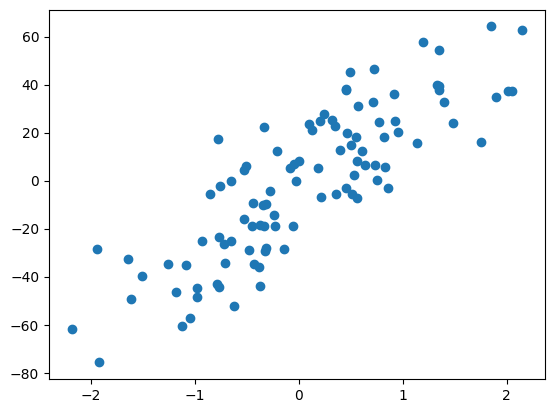

In [5]:
plt.scatter(X,y)
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(x_train,y_train)
print(reg.coef_)
print(reg.intercept_)

c:\Users\vivek\OneDrive\Desktop\Machine Learning From Udemy\app\.venv\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\vivek\OneDrive\Desktop\Machine Learning From Udemy\app\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\vivek\OneDrive\Desktop\Machine Learning From Udemy\app\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.119e+04, tolerance: 7.984e+00
Linear regression models with a zero l1 penalization strength are more efficiently

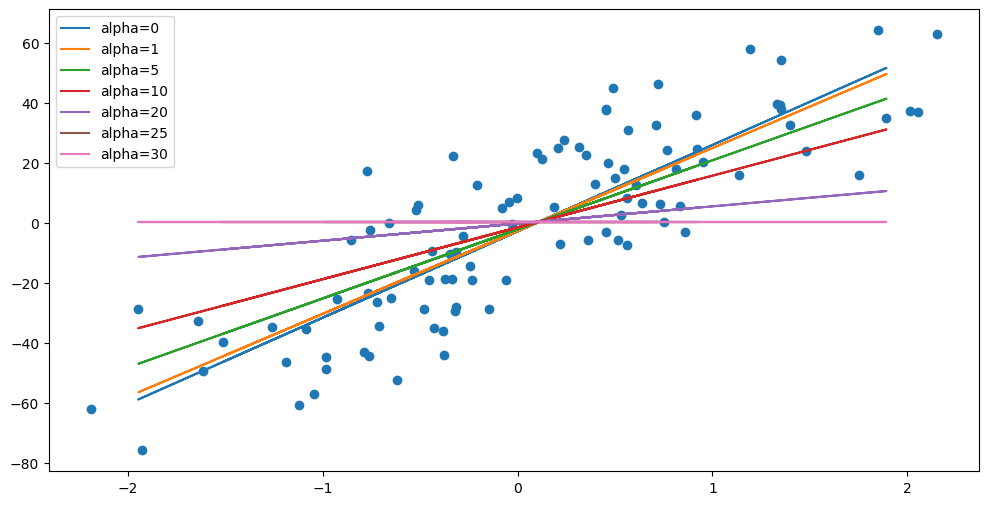

In [8]:
alpha=[0,1,5,10,20,25,30]
plt.figure(figsize=(12,6))
plt.scatter(X,y)
for i in alpha:
    L=Lasso(alpha=i)
    L.fit(x_train,y_train)
    plt.plot(x_test,L.predict(x_test),label='alpha={}'.format(i))
plt.legend()
plt.show()

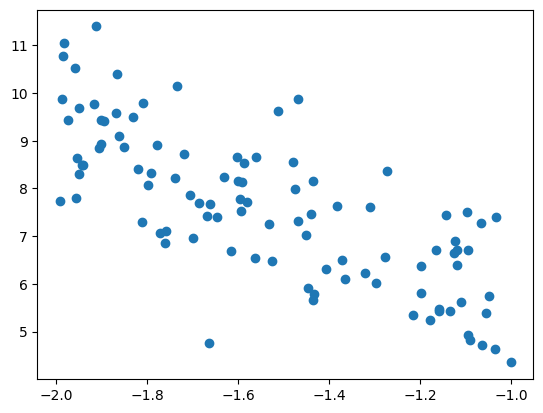

In [22]:
m=100
x1=np.random.rand(m,1)-2
x2=0.7* x1**2-2*x1+3+np.random.randn(m,1)
plt.scatter(x1,x2)
plt.show()

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

c:\Users\vivek\OneDrive\Desktop\Machine Learning From Udemy\app\.venv\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\vivek\OneDrive\Desktop\Machine Learning From Udemy\app\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\vivek\OneDrive\Desktop\Machine Learning From Udemy\app\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.219e+01, tolerance: 2.497e-02
Linear regression models with a zero l1 penalization strength are more efficiently

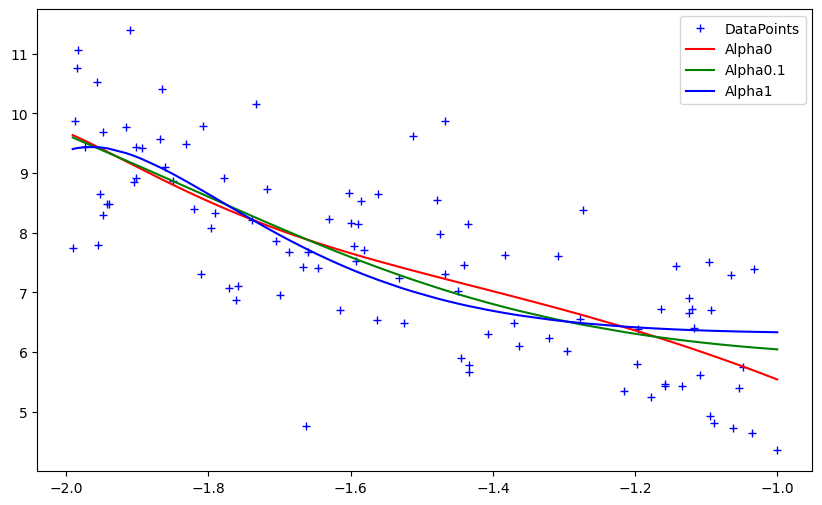

In [24]:
def get_preds_lasso(x1,x2,alpha):
    model=Pipeline([
    ('poly_feature',PolynomialFeatures(degree=16)),
    ('lasso',Lasso(alpha=alpha))
    ])
    model.fit(x1,x2)
    return model.predict(x1)
alphas=[0,0.1,1]
cs=['r','g','b']
plt.figure(figsize=(10,6))
plt.plot(x1,x2,'b+',label='DataPoints')
for alpha,c in zip(alphas,cs):
    preds=get_preds_lasso(x1,x2,alpha)
    plt.plot(sorted(x1[:,0]),preds[np.argsort(x1[:,0])],c,label='Alpha{}'.format(alpha))
plt.legend()
plt.show()
